In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

kid_df = pd.read_csv(r"C:\Jeeva\multiple_disease_prediction\kidney_disease_csv.csv")
kid_df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [103]:
#check dataset balance
kid_df1 = pd.read_csv(r"C:\Jeeva\multiple_disease_prediction\kidney_disease_csv.csv")
kid_df1.head()

print(kid_df1['classification'].value_counts())

classification
ckd       250
notckd    150
Name: count, dtype: int64


In [57]:
#check for nulls
kid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [31]:
# Number of nulls in each column
nulls_per_column = kid_df.isnull().sum()
print(nulls_per_column)

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64


In [17]:
# Percentage of nulls in each column
nulls_percentage = kid_df.isnull().mean() * 100
print(nulls_percentage)

id                 0.00
age                2.25
bp                 3.00
sg                11.75
al                11.50
su                12.25
rbc               38.00
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 4.75
sc                 4.25
sod               21.75
pot               22.00
hemo              13.00
pcv               17.50
wc                26.25
rc                32.50
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64


In [59]:
#drop columns
drop_columns = ['id','rbc','rc','wc']
kid_df.drop(columns = drop_columns,inplace=True)

In [37]:
# Percentage of nulls in each column
nulls_percentage = kid_df.isnull().mean() * 100
print(nulls_percentage)

age                2.25
bp                 3.00
sg                11.75
al                11.50
su                12.25
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 4.75
sc                 4.25
sod               21.75
pot               22.00
hemo              13.00
pcv               17.50
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64


In [39]:
#check for nulls
kid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   pc              335 non-null    object 
 6   pcc             396 non-null    object 
 7   ba              396 non-null    object 
 8   bgr             356 non-null    float64
 9   bu              381 non-null    float64
 10  sc              383 non-null    float64
 11  sod             313 non-null    float64
 12  pot             312 non-null    float64
 13  hemo            348 non-null    float64
 14  pcv             330 non-null    object 
 15  htn             398 non-null    object 
 16  dm              398 non-null    object 
 17  cad             398 non-null    obj

In [43]:
kid_df.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [87]:
#impute missing age value with median
kid_df['age'].fillna(kid_df['age'].median(),inplace=True)

#impute missing bp value with median
kid_df['bp'].fillna(kid_df['bp'].median(),inplace=True)

#impute missing sg value with median
kid_df['sg'].fillna(kid_df['sg'].median(),inplace=True)

#impute missing al value with median
kid_df['al'].fillna(kid_df['al'].median(),inplace=True)

#impute missing al value with median
kid_df['su'].fillna(kid_df['su'].median(),inplace=True)

#impute missing sg value with median
kid_df['bgr'].fillna(kid_df['bgr'].median(),inplace=True)

#impute missing sg value with median
kid_df['bu'].fillna(kid_df['bu'].median(),inplace=True)

#impute missing sc value with median
kid_df['sc'].fillna(kid_df['sc'].median(),inplace=True)

#impute missing sod value with median
kid_df['sod'].fillna(kid_df['sod'].median(),inplace=True)

#impute missing sg value with median
kid_df['pot'].fillna(kid_df['pot'].median(),inplace=True)

#impute missing hemo value with median
kid_df['hemo'].fillna(kid_df['hemo'].median(),inplace=True)

C:\Users\JEEVA\AppData\Local\Temp\ipykernel_1892\1144028418.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kid_df['age'].fillna(kid_df['age'].median(),inplace=True)
C:\Users\JEEVA\AppData\Local\Temp\ipykernel_1892\1144028418.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [111]:
kid_df.tail()
# Print only categorical columns
categorical_columns = kid_df.select_dtypes(include=['object', 'category'])
print(categorical_columns)
categorical_columns.isnull().mean()* 100

           pc         pcc          ba pcv  htn   dm cad appet   pe  ane  \
0      normal  notpresent  notpresent  44  yes  yes  no  good   no   no   
1      normal  notpresent  notpresent  38   no   no  no  good   no   no   
2      normal  notpresent  notpresent  31   no  yes  no  poor   no  yes   
3    abnormal     present  notpresent  32  yes   no  no  poor  yes  yes   
4      normal  notpresent  notpresent  35   no   no  no  good   no   no   
..        ...         ...         ...  ..  ...  ...  ..   ...  ...  ...   
395    normal  notpresent  notpresent  47   no   no  no  good   no   no   
396    normal  notpresent  notpresent  54   no   no  no  good   no   no   
397    normal  notpresent  notpresent  49   no   no  no  good   no   no   
398    normal  notpresent  notpresent  51   no   no  no  good   no   no   
399    normal  notpresent  notpresent  53   no   no  no  good   no   no   

    classification  
0              ckd  
1              ckd  
2              ckd  
3              

pc                16.25
pcc                1.00
ba                 1.00
pcv               17.50
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64

In [129]:
categorical_columns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   pc              335 non-null    object
 1   pcc             396 non-null    object
 2   ba              396 non-null    object
 3   pcv             330 non-null    object
 4   htn             398 non-null    object
 5   dm              398 non-null    object
 6   cad             398 non-null    object
 7   appet           399 non-null    object
 8   pe              399 non-null    object
 9   ane             399 non-null    object
 10  classification  400 non-null    object
dtypes: object(11)
memory usage: 34.5+ KB


In [131]:
categorical_columns.drop(columns=['pcv'])
# Apply mode imputation for categorical columns
kid_df[categorical_columns.columns] = categorical_columns.apply(lambda x: x.fillna(x.mode()[0]))

In [133]:
kid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   pc              400 non-null    object 
 6   pcc             400 non-null    object 
 7   ba              400 non-null    object 
 8   bgr             400 non-null    float64
 9   bu              400 non-null    float64
 10  sc              400 non-null    float64
 11  sod             400 non-null    float64
 12  pot             400 non-null    float64
 13  hemo            400 non-null    float64
 14  pcv             400 non-null    object 
 15  htn             400 non-null    object 
 16  dm              400 non-null    object 
 17  cad             400 non-null    obj

In [141]:
# Select only numerical columns
numerical_columns = kid_df.select_dtypes(include=['number'])

# Calculate Pearson correlation for numerical columns
pearson_corr = numerical_columns.corr(method='pearson')
print(pearson_corr)

# Calculate Spearman correlation for numerical columns
spearman_corr = numerical_columns.corr(method='spearman')
print(spearman_corr)



           age        bp        sg        al        su       bgr        bu  \
age   1.000000  0.136316 -0.160374  0.085918  0.186750  0.230731  0.194291   
bp    0.136316  1.000000 -0.166980  0.123518  0.189561  0.150180  0.180841   
sg   -0.160374 -0.166980  1.000000 -0.479962 -0.292053 -0.299413 -0.244995   
al    0.085918  0.123518 -0.479962  1.000000  0.287751  0.293150  0.347418   
su    0.186750  0.189561 -0.292053  0.287751  1.000000  0.627002  0.126897   
bgr   0.230731  0.150180 -0.299413  0.293150  0.627002  1.000000  0.118859   
bu    0.194291  0.180841 -0.244995  0.347418  0.126897  0.118859  1.000000   
sc    0.133985  0.143184 -0.171998  0.161310  0.096434  0.068886  0.581517   
sod  -0.086040 -0.100705  0.210791 -0.225612 -0.051758 -0.130569 -0.308806   
pot   0.049399  0.063667 -0.052935  0.107893  0.177396  0.052732  0.339771   
hemo -0.178308 -0.279303  0.490699 -0.474399 -0.156807 -0.254435 -0.541635   

            sc       sod       pot      hemo  
age   0.133985 -

In [143]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical columns
label_encoder = LabelEncoder()
for col in kid_df.select_dtypes(include=['object']).columns:
    kid_df[col] = label_encoder.fit_transform(kid_df[col])


# Now, calculate correlation including previously categorical columns
pearson_corr = kid_df.corr(method='pearson')
print(pearson_corr)

                     age        bp        sg        al        su        pc  \
age             1.000000  0.136316 -0.160374  0.085918  0.186750 -0.102286   
bp              0.136316  1.000000 -0.166980  0.123518  0.189561 -0.156231   
sg             -0.160374 -0.166980  1.000000 -0.479962 -0.292053  0.365353   
al              0.085918  0.123518 -0.479962  1.000000  0.287751 -0.561713   
su              0.186750  0.189561 -0.292053  0.287751  1.000000 -0.190062   
pc             -0.102286 -0.156231  0.365353 -0.561713 -0.190062  1.000000   
pcc             0.157401  0.056808 -0.306426  0.417868  0.168091 -0.520118   
ba              0.042427  0.110164 -0.231704  0.377935  0.119399 -0.330401   
bgr             0.230731  0.150180 -0.299413  0.293150  0.627002 -0.247665   
bu              0.194291  0.180841 -0.244995  0.347418  0.126897 -0.344501   
sc              0.133985  0.143184 -0.171998  0.161310  0.096434 -0.158038   
sod            -0.086040 -0.100705  0.210791 -0.225612 -0.051758

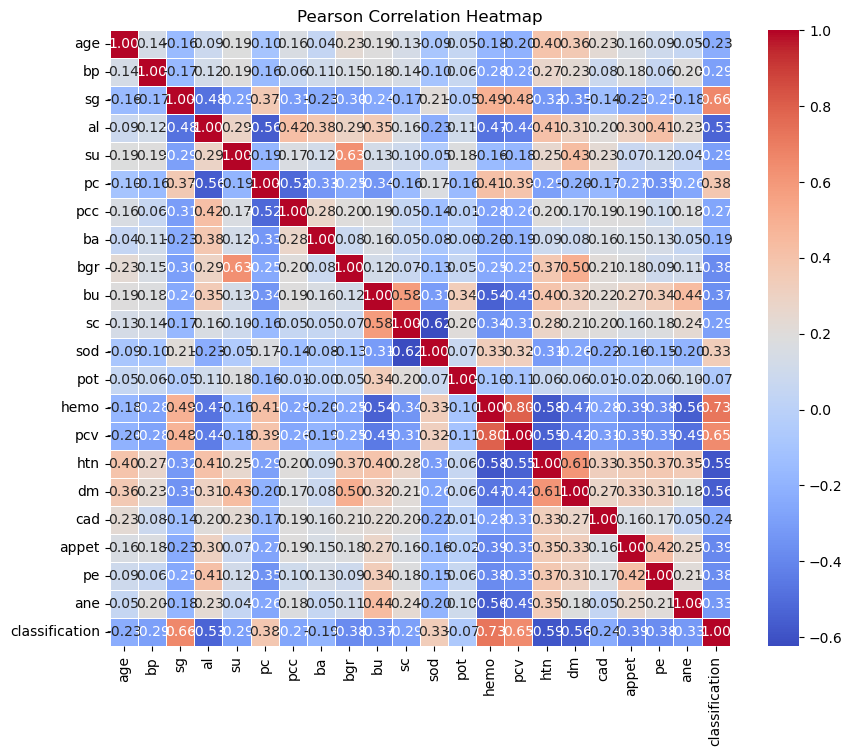

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the Pearson correlation for numerical columns
numerical_columns = kid_df.select_dtypes(include=['number'])
pearson_corr = numerical_columns.corr(method='pearson')

# Create a heatmap for Pearson correlation
plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Pearson Correlation Heatmap")
plt.show()


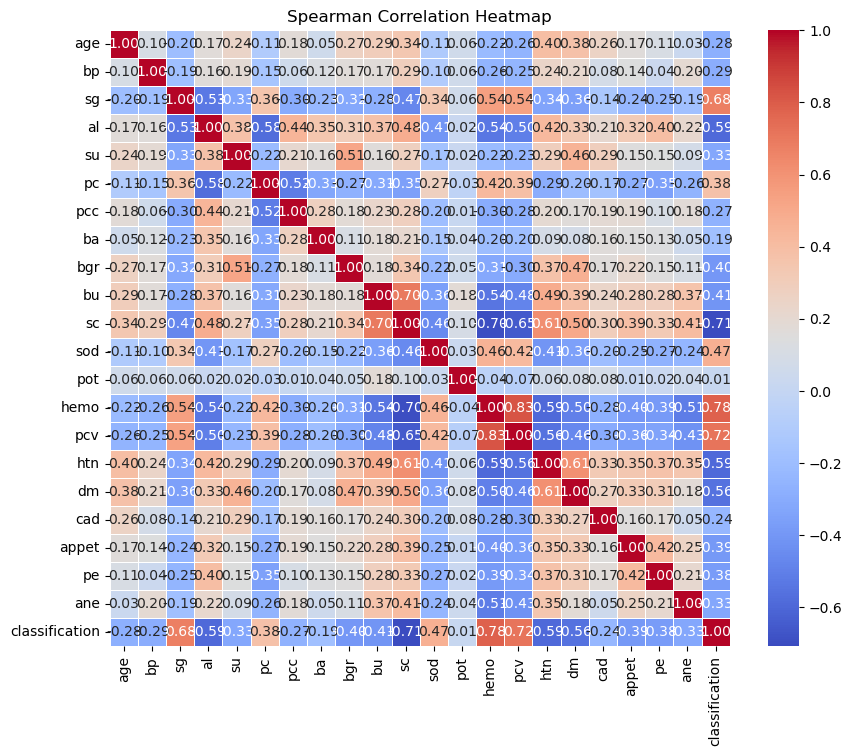

In [147]:
# Calculate the Spearman correlation for numerical columns
spearman_corr = numerical_columns.corr(method='spearman')

# Create a heatmap for Spearman correlation
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()


In [169]:
# Select numerical columns
numerical_columns = kid_df.select_dtypes(include=['number'])

# Calculate Pearson correlation for numerical columns
pearson_corr = numerical_columns.corr(method='pearson')

# Select the correlations with the target variable
target_corr = pearson_corr['classification'].sort_values(ascending=False)

# Select top 10 features based on correlation with the target
top_10_features = target_corr.index[1:11]  # Exclude the target column itself
print("Top 10 features:", top_10_features)

# Add classification column (target variable column)
classification_column = kid_df['classification']

# Check for balance in the dataset
class_distribution = classification_column.value_counts()
print("Class distribution in the target column:")
print(class_distribution)

# Check if the dataset is balanced
if class_distribution.min() / class_distribution.max() > 0.2:
    print("Dataset is balanced.")
else:
    print("Dataset is imbalanced.")



Top 10 features: Index(['hemo', 'sg', 'pcv', 'pc', 'sod', 'pot', 'ba', 'age', 'cad', 'pcc'], dtype='object')
Class distribution in the target column:
classification
0    250
1    150
Name: count, dtype: int64
Dataset is balanced.


In [171]:
X = kid_df[top_10_features]
y = kid_df['classification']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [179]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the classifier
model = RandomForestClassifier(n_estimators=100,max_depth=10, random_state=42)

# Train the model
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

In [181]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed evaluation
print(classification_report(y_test, y_pred))


Accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.93      1.00      0.97        28

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [177]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)


{'max_depth': 10, 'n_estimators': 100}


In [183]:
import joblib
joblib.dump(model, 'kidney_model.pkl')


['kidney_model.pkl']

In [185]:
#random forest classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = kid_df[top_10_features]
y = kid_df['classification']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the classifier
model = RandomForestClassifier(n_estimators=100,max_depth=10, random_state=42)

# Train the model
model.fit(X_train, y_train)


# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed evaluation
print(classification_report(y_test, y_pred))


Accuracy: 0.975
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.93      1.00      0.97        28

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [191]:
from xgboost import XGBClassifier

X = kid_df[top_10_features]
y = kid_df['classification']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(xgb_model, 'kidney_model_xgboost_model.pkl')

C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:43:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.975
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        52
           1       0.93      1.00      0.97        28

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



['kidney_model_xgboost_model.pkl']

In [193]:
# Feature importance for Random Forest
import pandas as pd

# Get feature importances from Random Forest
rf_feature_importance = model.feature_importances_

# Create a DataFrame for better visualization
rf_feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_feature_importance
})

# Sort by importance
rf_feature_df = rf_feature_df.sort_values(by='Importance', ascending=False)
print("Random Forest Feature Importance:")
print(rf_feature_df)

# Feature importance for XGBoost
xgb_feature_importance = xgb_model.feature_importances_

# Create a DataFrame for better visualization
xgb_feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_feature_importance
})

# Sort by importance
xgb_feature_df = xgb_feature_df.sort_values(by='Importance', ascending=False)
print("XGBoost Feature Importance:")
print(xgb_feature_df)


Random Forest Feature Importance:
  Feature  Importance
0    hemo    0.415924
2     pcv    0.201102
1      sg    0.194171
4     sod    0.085306
7     age    0.041470
5     pot    0.039372
3      pc    0.015278
8     cad    0.003483
6      ba    0.002032
9     pcc    0.001862
XGBoost Feature Importance:
  Feature  Importance
0    hemo    0.489943
1      sg    0.462370
4     sod    0.021651
7     age    0.015854
2     pcv    0.007008
5     pot    0.003173
3      pc    0.000000
6      ba    0.000000
8     cad    0.000000
9     pcc    0.000000


In [195]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Initialize the classifier
model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Perform 5-fold cross-validation
cv_scores_rf = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')

# Print cross-validation results
print("Random Forest Cross-Validation Scores:", cv_scores_rf)
print("Mean Accuracy: ", np.mean(cv_scores_rf))
print("Standard Deviation: ", np.std(cv_scores_rf))


Random Forest Cross-Validation Scores: [0.9625 0.9875 0.9375 0.975  0.9875]
Mean Accuracy:  0.9700000000000001
Standard Deviation:  0.018708286933869722


In [197]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the XGBoost classifier
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Perform 5-fold cross-validation
cv_scores_xgb = cross_val_score(model_xgb, X, y, cv=5, scoring='accuracy')

# Print cross-validation results
print("XGBoost Cross-Validation Scores:", cv_scores_xgb)
print("Mean Accuracy: ", np.mean(cv_scores_xgb))
print("Standard Deviation: ", np.std(cv_scores_xgb))


C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\JEEVA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:47:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

XGBoost Cross-Validation Scores: [0.975  0.9875 0.9625 0.9375 0.9875]
Mean Accuracy:  0.97
Standard Deviation:  0.01870828693386972
